In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [2]:
df=pd.read_csv("..\\data\\yield_df_cleaned.csv")
df.sample(10)

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
15838,Kazakhstan,Soybeans,2001,13561,250.0,3007.26,3.85
6641,Dominican Republic,"Rice, paddy",1997,48213,1410.0,3846.00,27.01
25135,Ukraine,Maize,1999,25220,565.0,32272.25,8.97
16641,Madagascar,"Rice, paddy",1991,20546,1513.0,131.00,19.79
19847,Nicaragua,"Rice, paddy",2010,51406,2280.0,12242.19,27.01
10556,India,Maize,1994,14480,1083.0,61357.00,26.55
22002,Rwanda,Maize,2009,19503,1212.0,1187.60,19.84
24610,Turkey,Soybeans,2004,35714,593.0,28831.00,17.97
3816,Brazil,Sorghum,2008,24105,1761.0,312637.00,25.54
13907,Indonesia,"Rice, paddy",2007,47052,2702.0,1597.00,27.29


In [3]:
df.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [4]:
df.Item.unique()

array(['Maize', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Wheat',
       'Cassava', 'Sweet potatoes', 'Plantains and others', 'Yams'],
      dtype=object)

In [5]:
df['Item'] = df['Item'].replace('Rice, paddy', 'Rice')

In [6]:
df.Item.unique()

array(['Maize', 'Potatoes', 'Rice', 'Sorghum', 'Soybeans', 'Wheat',
       'Cassava', 'Sweet potatoes', 'Plantains and others', 'Yams'],
      dtype=object)

In [7]:
X = df.drop(columns=['hg/ha_yield'])
y = df['hg/ha_yield']
X.head()

,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,1485.0,121.0,16.37
1,Albania,Potatoes,1990,1485.0,121.0,16.37
2,Albania,Rice,1990,1485.0,121.0,16.37
3,Albania,Sorghum,1990,1485.0,121.0,16.37
4,Albania,Soybeans,1990,1485.0,121.0,16.37


In [8]:
y.head()

0    36613
1    66667
2    23333
3    12500
4     7000
Name: hg/ha_yield, dtype: int64

In [9]:
X = pd.get_dummies(X,columns=['Area','Item'],drop_first=True,dtype=int)
X

,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area_Algeria,Area_Angola,Area_Argentina,Area_Armenia,Area_Australia,Area_Austria,...,Area_Zimbabwe,Item_Maize,Item_Plantains and others,Item_Potatoes,Item_Rice,Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,1990,1485.0,121.00,16.37,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,1990,1485.0,121.00,16.37,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,1990,1485.0,121.00,16.37,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,1990,1485.0,121.00,16.37,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1990,1485.0,121.00,16.37,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25927,2013,657.0,2550.07,19.76,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
25928,2013,657.0,2550.07,19.76,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
25929,2013,657.0,2550.07,19.76,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
25930,2013,657.0,2550.07,19.76,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0


In [10]:
joblib.dump(X.columns.tolist(), '../models/yield_columns.pkl')

['../models/yield_columns.pkl']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [12]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [13]:
lr.coef_

array([ 1.07226017e+03, -7.69012188e+00,  2.58958096e-02,  1.31763306e+01,
       -8.13746608e+03, -4.30130500e+04,  1.27708535e+04, -1.26677384e+04,
        4.77372539e+04,  5.54518457e+04, -2.07802308e+04, -3.65601413e+04,
       -2.67383071e+04, -8.54219861e+02, -6.46243215e+03,  1.32150666e+05,
       -2.17069641e+04, -3.26518426e+03, -8.70368874e+03, -5.35726438e+04,
       -4.18430989e+04, -3.37745935e+04, -3.32057136e+03, -7.10421225e+04,
        1.45265201e+04,  8.21162164e+02,  4.84602076e+03,  9.61458315e+04,
       -2.91122663e+04, -3.51979808e+04,  4.60827754e+04,  1.11227371e+04,
       -5.87509681e+04, -2.12292203e+04,  2.81468250e+04,  6.04635055e+04,
        7.68188881e+04, -2.88235395e+04,  2.72607416e+04,  1.35905362e+04,
       -4.30581603e+04, -2.30148021e+04, -5.13888528e+04, -1.84217410e+04,
        8.90618426e+03,  8.00533517e+03,  6.40855380e+03, -1.75252383e+04,
        9.60529703e+04,  3.71267830e+04,  1.46357836e+04,  5.73279184e+04,
       -1.77517433e+04, -

In [14]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse = mean_squared_error(y_test, y_pred_lr)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred_lr)

print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MSE : 1813156602.4008138
RMSE: 42581.17662067142
R2  : 0.7489788180498694


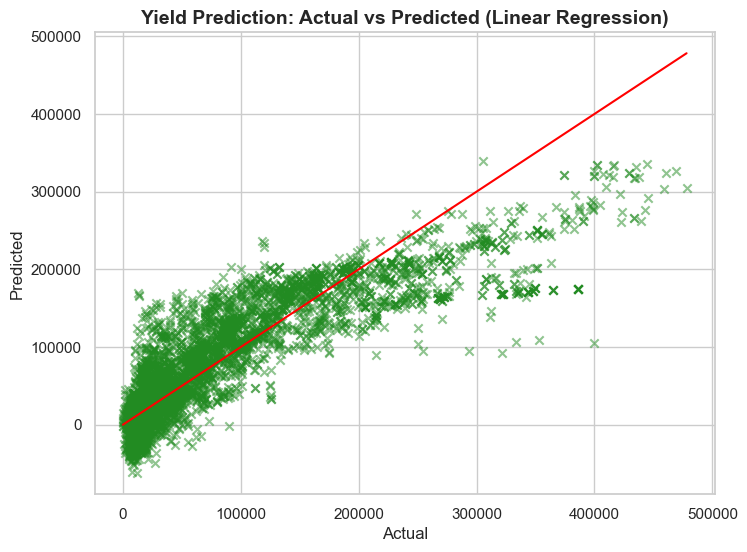

In [15]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.set_theme(style="whitegrid", palette="GnBu")
plt.scatter(y_test,y_pred_lr,alpha=0.5,c='forestgreen',marker='x')

plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],c='Red')

plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.title('Yield Prediction: Actual vs Predicted (Linear Regression)',fontweight='bold',fontsize=14)

plt.show()

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred_rf = rf.predict(X_test)

In [18]:
mse_rf = mean_squared_error(y_test,y_pred_rf)
rmse_rf = mse_rf**0.5
r2_rf = r2_score(y_test,y_pred_rf)

print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

MSE : 85998388.00426947
RMSE: 9273.531582103415
R2  : 0.9880940140669296


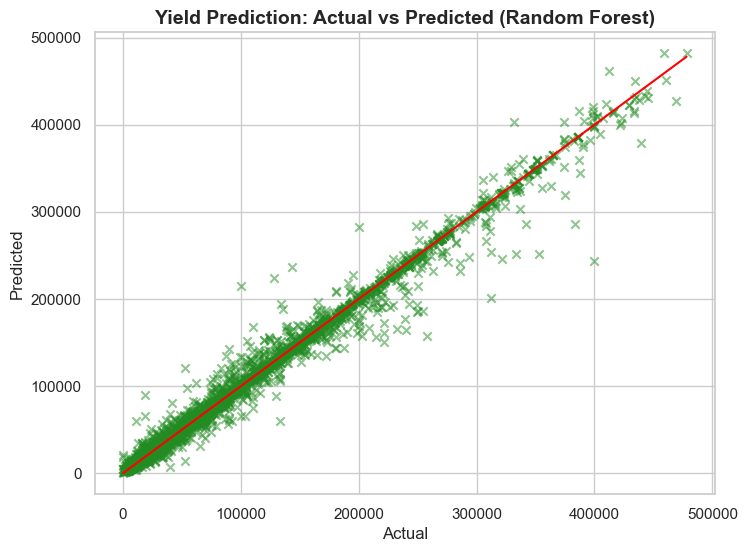

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred_rf,alpha=0.5,c='forestgreen',marker='x')

plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],c='Red')

plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.title('Yield Prediction: Actual vs Predicted (Random Forest)',fontweight='bold',fontsize=14)

plt.show()

In [20]:
from sklearn.tree import DecisionTreeRegressor as DTR

dt = DTR(max_depth=None)

dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [21]:
y_pred_dt = dt.predict(X_test)

In [22]:
mse_dt = mean_squared_error(y_test,y_pred_dt)
rmse_dt = mse_dt**0.5
r2_dt = r2_score(y_test,y_pred_dt)

print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R2  :", r2_dt)

MSE : 128841667.99537306
RMSE: 11350.84437367428
R2  : 0.9821626065052513


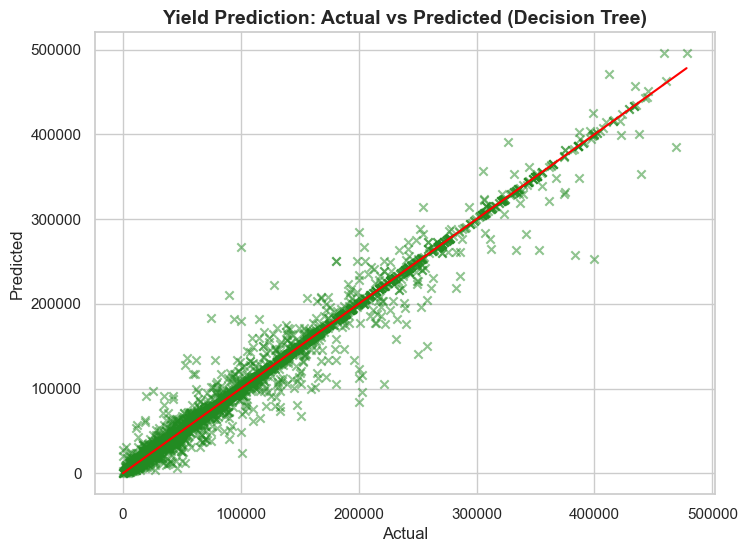

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred_dt,alpha=0.5,c='forestgreen',marker='x')

plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],c='Red')

plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.title('Yield Prediction: Actual vs Predicted (Decision Tree)',fontweight='bold',fontsize=14)

plt.show()

In [24]:
comparison = pd.DataFrame({
    'Model':['Linear Regression','Decision Tree','Random Forest'],
    'MSE':[mse,mse_dt,mse_rf],
    'RMSE':[rmse,rmse_dt,rmse_rf],
    'R2':[r2,r2_dt,r2_rf]
})

comparison

,Model,MSE,RMSE,R2
0,Linear Regression,1.813157e+09,42581.176621,0.748979
1,Decision Tree,1.288417e+08,11350.844374,0.982163
2,Random Forest,8.599839e+07,9273.531582,0.988094


In [25]:
importance_dt = pd.DataFrame({
    'Feature':X.columns,
    'Importance':dt.feature_importances_
})

importance_dt = importance_dt.sort_values(by='Importance',ascending=False)
importance_dt

,Feature,Importance
106,Item_Potatoes,3.728806e-01
2,pesticides_tonnes,7.026384e-02
110,Item_Sweet potatoes,6.599264e-02
107,Item_Rice,6.564165e-02
45,Area_India,5.834480e-02
...,...,...
54,Area_Latvia,2.447812e-06
25,Area_Colombia,2.220968e-06
12,Area_Bahrain,3.212213e-07
66,Area_Montenegro,5.925382e-08


In [26]:
importance_rf = pd.DataFrame({'Feature':X.columns,'Importance':rf.feature_importances_})
importance_rf = importance_rf.sort_values(by='Importance',ascending=False)
importance_rf

,Feature,Importance
106,Item_Potatoes,0.372388
2,pesticides_tonnes,0.074541
107,Item_Rice,0.066560
110,Item_Sweet potatoes,0.066327
45,Area_India,0.050496
...,...,...
96,Area_Tunisia,0.000014
70,Area_Nepal,0.000013
33,Area_Estonia,0.000008
66,Area_Montenegro,0.000006


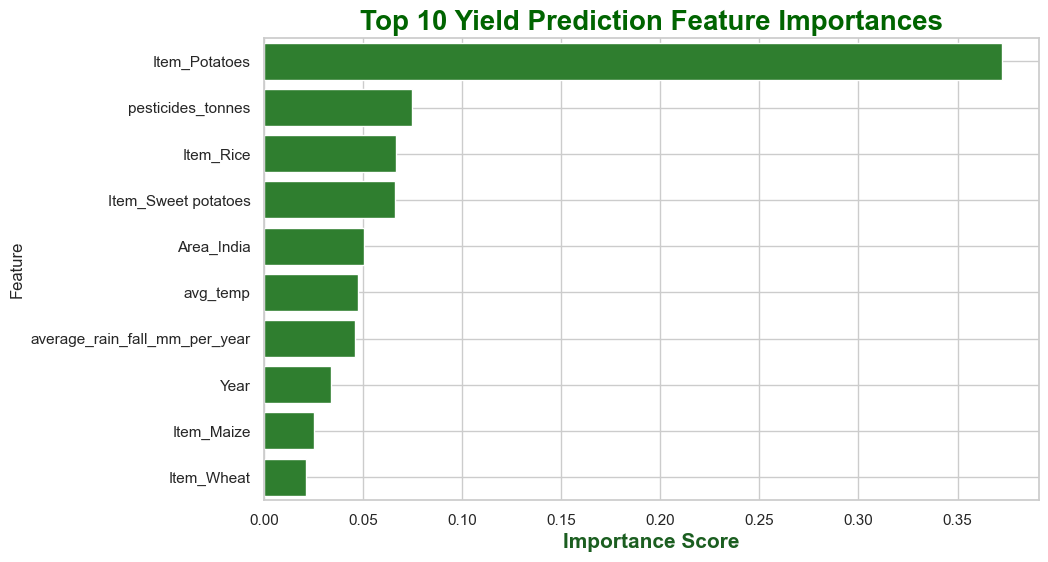

In [27]:
plt.figure(figsize=(10,6))
top10=importance_rf.head(10)
sns.barplot(data=top10,x=top10['Importance'],y=top10['Feature'],color='forestgreen')
plt.title('Top 10 Yield Prediction Feature Importances',fontsize=20,fontweight='bold',color='darkgreen')
plt.xlabel('Importance Score',fontsize=15,fontweight='bold',color='#1B5E20')
plt.grid(True)

Saving the models

In [28]:
joblib.dump(rf, '../models/yield_prediction_model_RFR.pkl')

['../models/yield_prediction_model_RFR.pkl']

In [29]:
df.sample().drop(columns='hg/ha_yield')

,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
8444,Germany,Potatoes,2000,700.0,35273.17,10.96


In [30]:
df.iloc[3782,3]

np.int64(40800)